C:\Users\jupik\AppData\Local\Temp\ipykernel_23532\2801091458.py:17: RuntimeWarning: overflow encountered in exp
  intensity = a / (wavelength**5 * (np.exp(b) - 1.0))


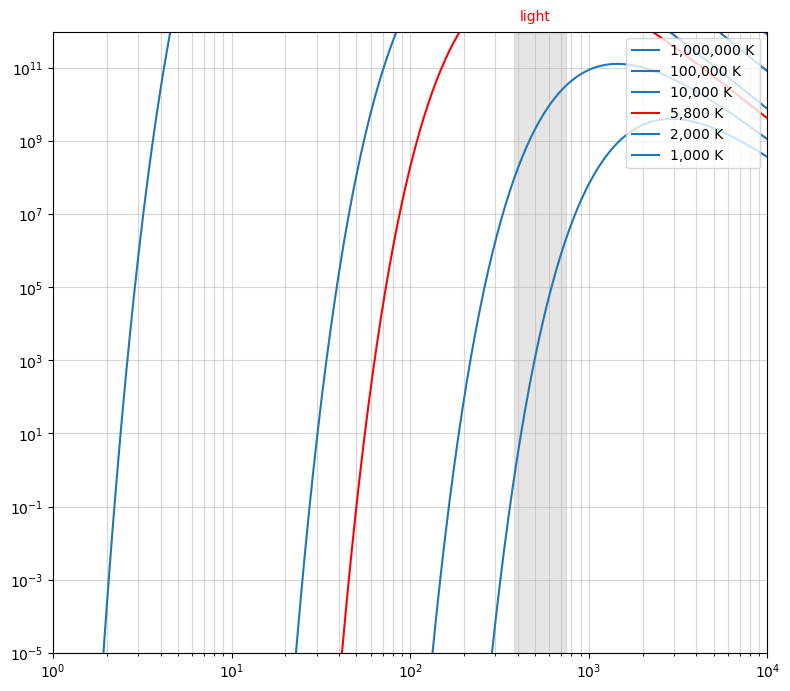

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 物理定数の定義
h = 6.626e-34    # プランク定数 [J·s]
c = 3.0e8        # 光速 [m/s]
kB = 1.38e-23    # ボルツマン定数 [J/K]

def planck_law(wavelength, T):
    """
    プランクの法則に基づく放射強度を計算する関数
    wavelength: 波長 [m]
    T: 絶対温度 [K]
    """
    a = 2.0 * h * c**2
    b = h * c / (wavelength * kB * T)
    intensity = a / (wavelength**5 * (np.exp(b) - 1.0))
    return intensity

# 波長範囲の設定 (1nm から 10000nm まで)
wavelengths = np.logspace(0, 4, 500) * 1e-9  # メートル単位に変換

# 描画する温度リスト
temperatures = [1000000, 100000, 10000, 5800, 2000, 1000]

# グラフの作成
plt.figure(figsize=(8, 7))

for T in temperatures:
    intensity = planck_law(wavelengths, T)
    
    # 太陽の表面温度(5800K)だけ色を変えるなどの演出
    line_color = 'red' if T == 5800 else 'tab:blue'
    plt.plot(wavelengths * 1e9, intensity, label=f'{T:,} K', color=line_color)

# 軸の設定（両対数グラフ）
plt.xscale('log')
plt.yscale('log')

# 軸の範囲とラベル
plt.xlim(1, 10000)
plt.ylim(1e-5, 1e12)

# グリッドと凡例
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='upper right')

# 可視光領域などの注釈（
plt.axvspan(380, 750, color='gray', alpha=0.2) # 可視光領域の目安
plt.text(500, 2e12, 'light', horizontalalignment='center', color='red')

plt.tight_layout()
plt.show()